## fsdfsd

In [166]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [167]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10.0, 10.0)
matplotlib.rcParams['image.cmap'] = 'gray'

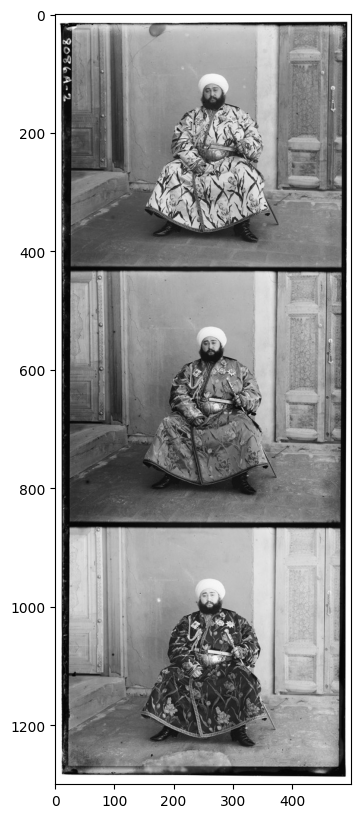

In [168]:
im = cv2.imread('data/images/emir.jpg', cv2.IMREAD_GRAYSCALE)

plt.imshow(im)

In [169]:
# Find the width and height of the color image
sz = im.shape
print(sz)

height = int(sz[0] / 3);
width = sz[1]

(1300, 500)


In [170]:
# Extract the three channels from the gray scale image
# and merge the three channels into one color image
im_color = np.zeros((height,width,3), dtype=np.uint8 )
for i in range(0,3) :
    im_color[:,:,i] = im[ i * height:(i+1) * height,:]

In [171]:
blue = im_color[:,:,0]
green = im_color[:,:,1]
red = im_color[:,:,2]

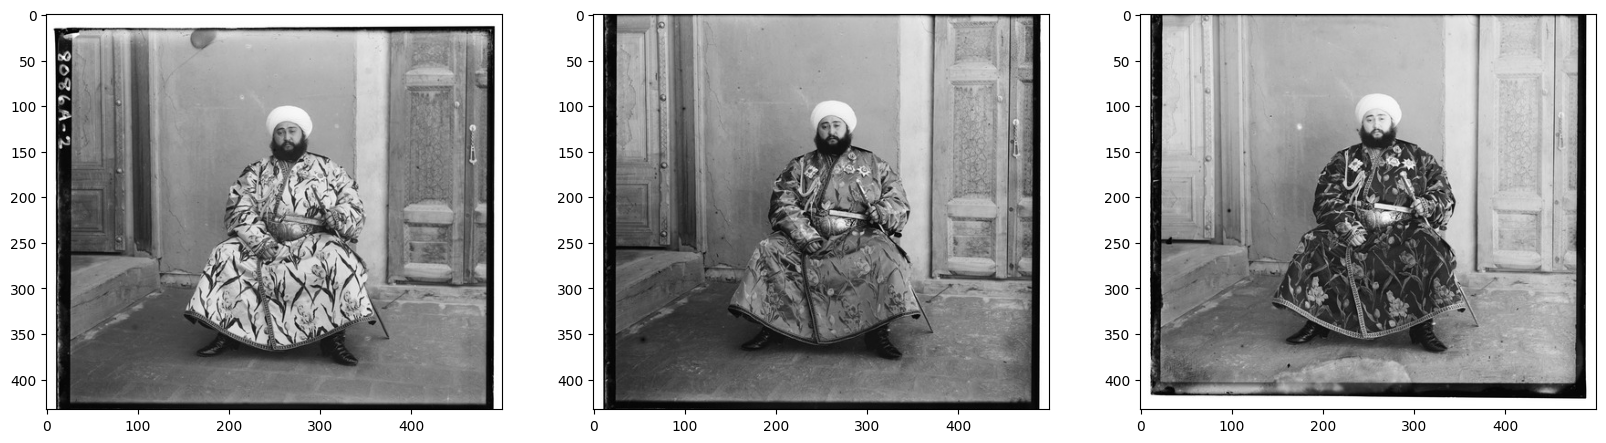

In [172]:
plt.figure(figsize=(20,12))
plt.subplot(1,3,1)
plt.imshow(blue)
plt.subplot(1,3,2)
plt.imshow(green)
plt.subplot(1,3,3)
plt.imshow(red)
plt.show()

In [173]:
MAX_FEATURES = 20000
GOOD_MATCH_PERCENT = 0.15

In [174]:
orb = cv2.ORB_create(MAX_FEATURES)
keypoints_blue, descriptors_blue = orb.detectAndCompute(blue, None)
keypoints_green, descriptors_green = orb.detectAndCompute(green, None)
keypoints_red, descriptors_red = orb.detectAndCompute(red, None)

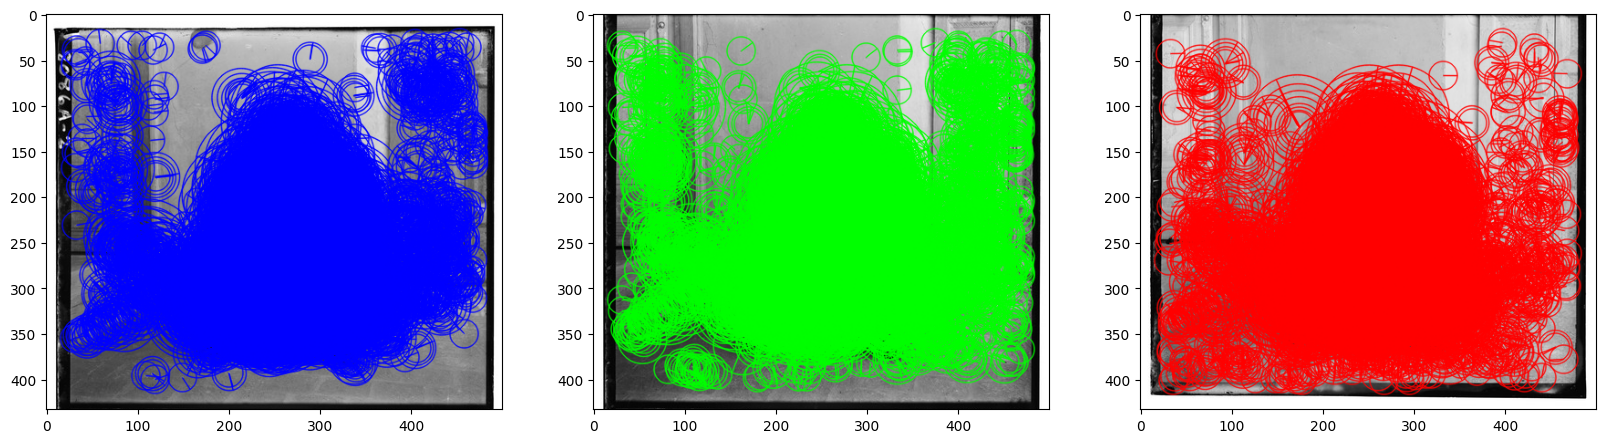

In [175]:
plt.figure(figsize=[20,10])
img2 = cv2.drawKeypoints(blue, keypoints_blue, None, color=(255,0,0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.subplot(131);plt.imshow(img2[...,::-1])

img2 = cv2.drawKeypoints(green, keypoints_green, None, color=(0,255,0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.subplot(132);plt.imshow(img2[...,::-1])

img2 = cv2.drawKeypoints(red, keypoints_red, None, color=(0,0,255), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.subplot(133);plt.imshow(img2[...,::-1])


In [176]:
# Match features.
###
matcher = cv2.DescriptorMatcher_create(cv2.DESCRIPTOR_MATCHER_BRUTEFORCE_HAMMING)
###

# Match features between blue and Green channels
###
matches_blue_green = list(matcher.match(descriptors_blue, descriptors_green))
###
# print(type(matches_blue_green))
# Sort matches by score
matches_blue_green.sort(key=lambda x: x.distance, reverse=False)

# Remove not so good matches
num_good_matches = int(len(matches_blue_green) * GOOD_MATCH_PERCENT)
matches_blue_green = matches_blue_green[:num_good_matches]

# Draw top matches
im_matches_blue_green = cv2.drawMatches(blue, keypoints_blue, green, keypoints_green, matches_blue_green, None)

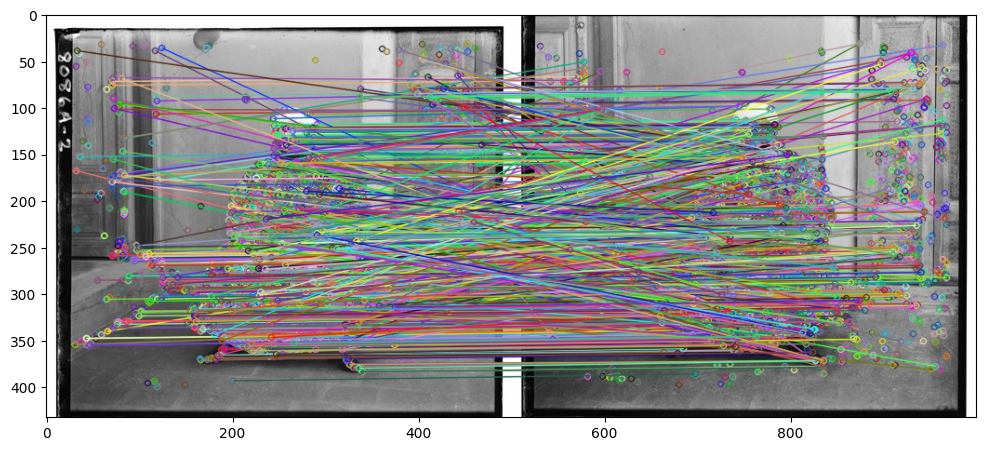

In [177]:
plt.figure(figsize=(12,12))
plt.imshow(im_matches_blue_green[:,:,::-1])
plt.show()

In [178]:
# Match features.
###
matcher = cv2.DescriptorMatcher_create(cv2.DESCRIPTOR_MATCHER_BRUTEFORCE_HAMMING)
###

# Match features between Red and Green channels
###
matches_red_green = list(matcher.match(descriptors_red, descriptors_green))
###

# Sort matches by score
matches_red_green.sort(key=lambda x: x.distance, reverse=False)

# Remove not so good matches
num_good_matches = int(len(matches_red_green) * GOOD_MATCH_PERCENT)
matches_red_green = matches_red_green[:num_good_matches]

# Draw top matches
im_matches_red_green = cv2.drawMatches(red, keypoints_red, green, keypoints_green, matches_red_green, None)

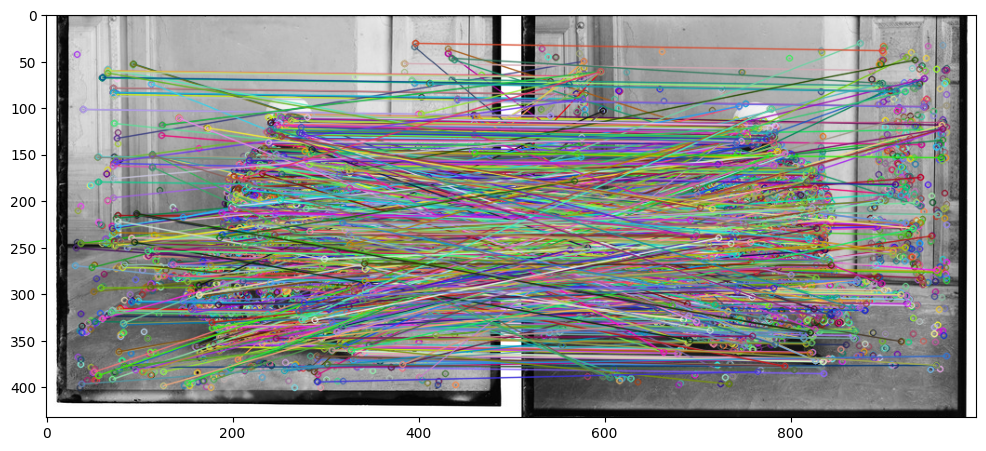

In [179]:
plt.figure(figsize=(12,12))
plt.imshow(im_matches_red_green[:,:,::-1])
plt.show()

In [180]:
# Extract location of good matches
points_blue = np.zeros((len(matches_blue_green), 2), dtype=np.float32)
points_green = np.zeros((len(matches_blue_green), 2), dtype=np.float32)

for i, match in enumerate(matches_blue_green):
    points_blue[i, :] = keypoints_blue[match.queryIdx].pt
    points_green[i, :] = keypoints_green[match.trainIdx].pt

# Find homography
hBlueGreen, mask = cv2.findHomography(points_blue, points_green, cv2.RANSAC)


In [181]:
points_red = np.zeros((len(matches_red_green), 2), dtype=np.float32)
points_green = np.zeros((len(matches_red_green), 2), dtype=np.float32)

for i, match in enumerate(matches_red_green):
    points_red[i, :] = keypoints_red[match.queryIdx].pt
    points_green[i, :] = keypoints_green[match.trainIdx].pt

# Find homography
hRedGreen, mask = cv2.findHomography(points_red, points_green, cv2.RANSAC)

Text(0.5, 1.0, 'Red channel aligned w.r.t green channel')

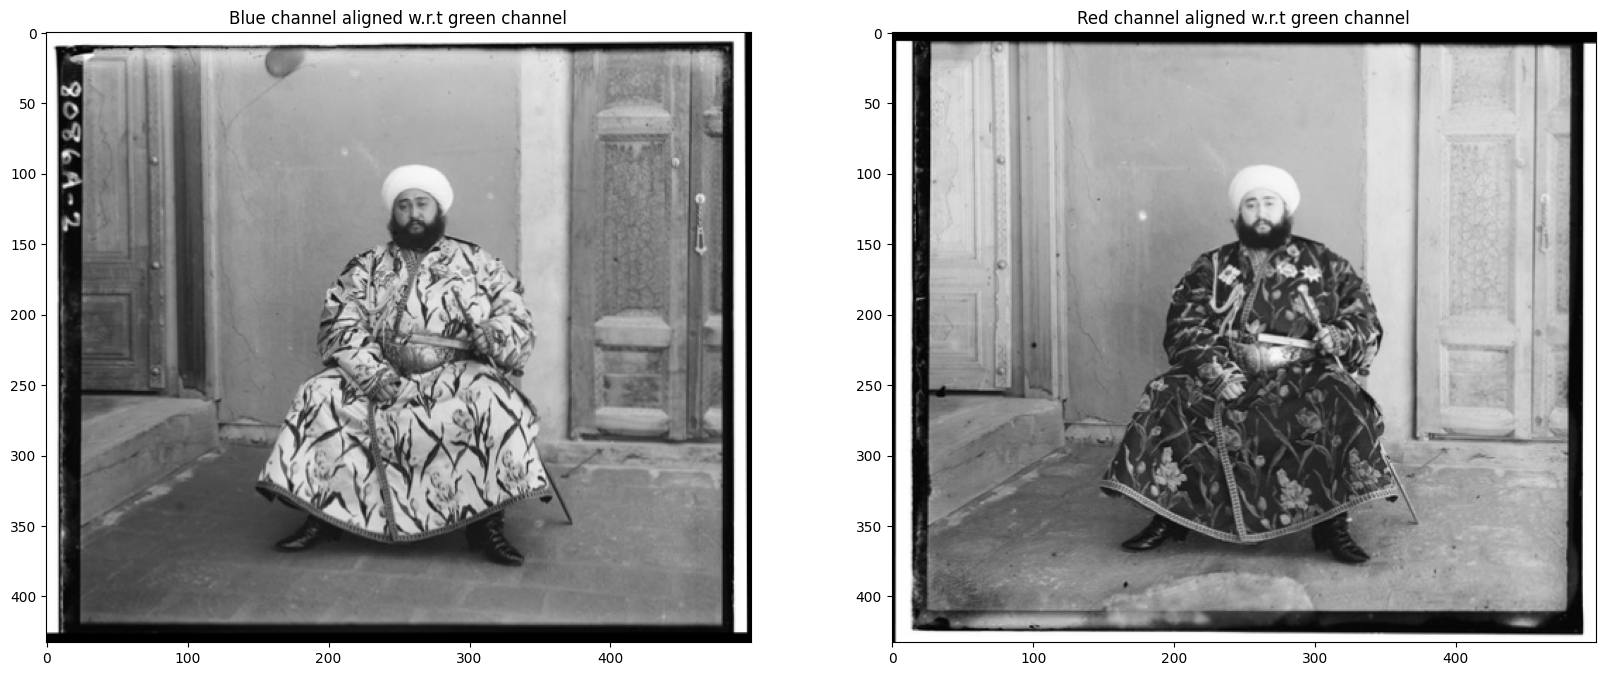

In [182]:
height, width = green.shape
blue_warped = cv2.warpPerspective(blue, hBlueGreen, (width, height))
red_warped = cv2.warpPerspective(red, hRedGreen, (width, height))
plt.figure(figsize=(20,10))
plt.subplot(121);plt.imshow(blue_warped);plt.title("Blue channel aligned w.r.t green channel")
plt.subplot(122);plt.imshow(red_warped);plt.title("Red channel aligned w.r.t green channel")

Text(0.5, 1.0, 'Aligned Image')

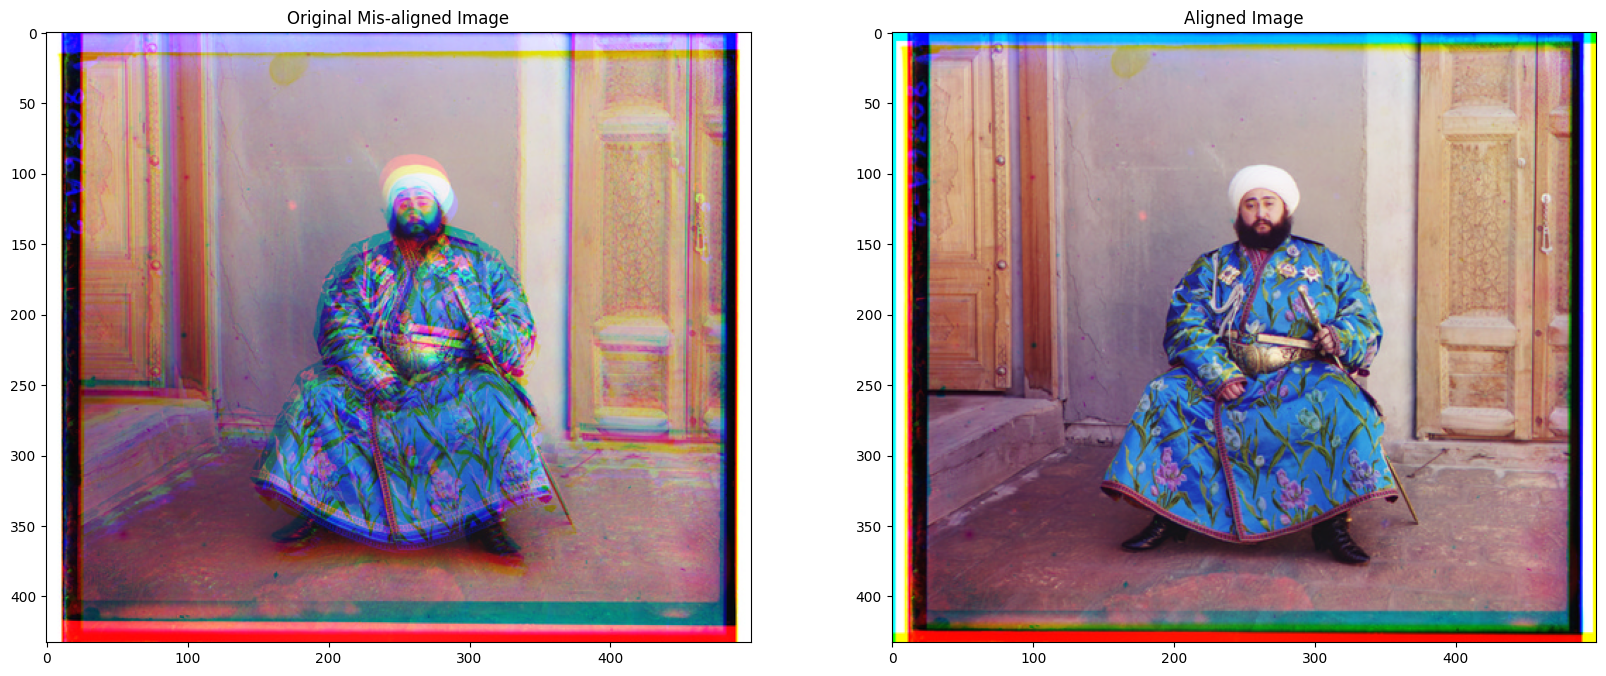

In [183]:
colorImage = cv2.merge((blue_warped,green,red_warped))
originalImage = cv2.merge((blue,green,red))

plt.figure(figsize=(20,10))
plt.subplot(121);plt.imshow(originalImage[:,:,::-1]);plt.title("Original Mis-aligned Image")
plt.subplot(122);plt.imshow(colorImage[:,:,::-1]);plt.title("Aligned Image")